<a href="https://colab.research.google.com/github/dhag/colab_demo/blob/main/%E5%BC%B7%E5%8C%96%E5%AD%A6%E7%BF%92%E3%81%A7S%E5%AD%97%E3%82%B3%E3%83%BC%E3%82%B9%E3%82%92%E8%B5%B0%E3%82%8B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 強化学習でS字コースを走る 🏎️
## 多数の車を一斉に走らせて学ぶ DQN（16方向ライダー・ハンドル/アクセル/ブレーキ・グリップ物理）

CartPole（倒立振子）に続く、より実践的な強化学習デモです。

- **タスク**：リセットのたびに形が変わる **S字コース** を、なるべく速くゴールまで走る
- **知覚（状態）**：車の中心から **16方向に測った壁までの距離**（ライダー）＋ 速度 ＋ 進行方向のズレ（19次元）
- **操作（行動）**：**ハンドル5段階**{左フル・左・直進・右・右フル} × **{アクセル・惰性・ブレーキ}** → 15通りの離散行動
- **物理**：**グリップ限界（フリクションサークル）** あり。横G＋縦Gの合成が μg を超えると **アンダーステア**で外へ膨らむ
- **報酬**：前進(＋)・速度(＋)・ゴール(＋)・衝突(−)・失速(−)・時間(−)。ラインは教えず**最短時間**だけを狙う
- **並列**：たくさんの車を同時に走らせて経験を稼ぐ。**車どうしは衝突しない**（壁だけ判定）
- **動画**：学習の途中（`video_every` ごと）に走りを動画化。色＝橙:走行 / 黄:グリップ超過 / 緑:ゴール / 灰:クラッシュ

> ⚙️ **GPU 推奨**：ランタイム → ランタイムのタイプを変更 → ハードウェアアクセラレータ = GPU


In [ ]:
# ============================================================
# 日本語フォント設定（matplotlib の豆腐(□)対策）。最初に必ず実行。
#   japanize-matplotlib → IPAexGothic → Noto CJK の順に自動設定。
# ============================================================
import matplotlib
import matplotlib.pyplot as plt

def setup_japanese_font():
    try:
        import japanize_matplotlib  # noqa: F401
        print("日本語フォント: japanize-matplotlib"); return
    except Exception:
        pass
    import os, subprocess, matplotlib.font_manager as fm
    cands = ["/usr/share/fonts/opentype/ipaexfont-gothic/ipaexg.ttf",
             "/usr/share/fonts/truetype/fonts-japanese-gothic.ttf"]
    if not any(os.path.exists(p) for p in cands):
        subprocess.run("apt-get -qq -y install fonts-ipaexfont", shell=True,
                       stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    for p in cands:
        if os.path.exists(p):
            fm.fontManager.addfont(p)
            matplotlib.rc("font", family=fm.FontProperties(fname=p).get_name())
            print("日本語フォント:", p); break
    else:
        matplotlib.rc("font", family="Noto Sans CJK JP")
        print("日本語フォント: Noto Sans CJK JP")

setup_japanese_font()
plt.rcParams["axes.unicode_minus"] = False


日本語フォント: /usr/share/fonts/opentype/ipaexfont-gothic/ipaexg.ttf


## 1. 環境（コース・知覚・操作・物理・報酬）

下のセルが環境の本体です。仕様とコードの対応：

- **S字コース生成** … `_gen_centerline()`：正弦波の振幅・周期・位相をランダム化。最小曲率半径が道幅に対して急になりすぎないよう振幅を自動調整
- **道路の自由空間** … `_build_mask()`：中心線から半幅以内を「道路」とする占有グリッド
- **16方向ライダー** … `_raycast()`：車の向き基準で全周16方向、壁までの距離をまとめて計算
- **車両運動＋グリップ物理** … `step()`：自転車モデル ＋ フリクションサークル
- **報酬** … 前進 ＋ 速度 ＋ ゴール − 衝突 − 失速 − 時間

> 🏁 **グリップ物理とレーシングライン（アウトインアウト）の創発**
> タイヤが出せる総加速度は `μg` まで（フリクションサークル）。コーナーを曲がるのに必要な横加速度は
> `a_lat = v²·tan(δ)/WB`。**速い＋急ハンドルだと `a_lat` がグリップを超え、指令ほど曲がれず外へ膨らむ（アンダーステア）** → 外側の壁に接触。
> さらにフルブレーキ中はグリップを使い切るので、**曲がりながらの減速は難しく、減速は直線で行う**のが有利。
> 報酬では**ラインを一切教えていない**（最短時間＝前進＋速度−時間 だけ）。それでもこの物理の下で最短時間を目指すと、
> **「コーナー手前で減速 → ラインを広く取り旋回を緩く（速度を保つ）→ 出口で加速」＝アウトインアウト**が自然に創発する。
>
> 💡 **失速対策**：自転車モデルは速度0だと舵が効かず固まるので、速度報酬＋「低速が続いたら失速終了（衝突より重い罰）」で“止まれば安全”を塞ぐ。
>
> 💡 **ゴール前の壁対策**：ゴールは末端の行き止まりより手前に置き（`goal_s`）、ゴール前方にライダー距離ぶんの道を残して減速・蛇行を防ぐ。


In [ ]:
# ============================================================================
# 【環境】 S字コースを走る車のシミュレータ（多数の車を同時にベクトル化）
#   ・コース  : リセットのたびにS字の湾曲をランダム生成（中心線＋半幅で道路を定義）
#   ・知覚    : 車の中心から「16方向」に壁までの距離を測る（ライダー）
#   ・操作    : ハンドル{左,直進,右} × ペダル{アクセル,惰性,ブレーキ} = 9通りの離散行動
#   ・目的    : なるべく速くゴールに到達（中心線に沿った前進＝報酬, 壁衝突＝罰）
#   ・並列    : n_cars 台を同時に走らせて経験を稼ぐ。車どうしは衝突しない（壁だけ判定）
# ============================================================================
import numpy as np

class STrackEnv:
    def __init__(self, n_cars=48, seed=None):
        self.n = n_cars
        self.rng = np.random.default_rng(seed)

        # ---- ワールドと占有グリッド（道路の自由空間を高速に判定するための格子）----
        self.WX, self.WY = 100.0, 60.0          # ワールドの大きさ（単位）
        self.cell = 0.5                          # 格子1マスの大きさ
        self.GW = int(self.WX / self.cell)       # 格子の幅（マス数）
        self.GH = int(self.WY / self.cell)
        self.half_w = 6.0                        # 道路の半幅（中心線からこの距離以内が道路）

        # ---- 車両パラメータ（自転車モデル ＋ グリップ限界）----
        self.dt = 0.15
        self.VMAX = 14.0                         # 最高速度
        self.ACC = 8.0                           # アクセル加速度
        self.BRK = 10.0                          # ブレーキ減速度
        self.DRAG = 1.2                          # 惰性（自然減速）
        self.WB = 2.5                            # ホイールベース
        self.MAXSTEER = np.deg2rad(32)           # 最大舵角（フルロックの前輪角）
        self.MU_G = 12.0                         # グリップ限界 μg（横G＋縦Gの合成がこれを超えるとアンダーステア）

        # ---- 知覚：16方向ライダー ----
        self.n_rays = 16
        self.ray_ang = np.linspace(0, 2*np.pi, self.n_rays, endpoint=False)  # 車の向き基準で全周16方向
        self.RANGE = 25.0                        # ライダーの最大計測距離
        self.n_step_samples = 80                 # 1本のレイを刻むサンプル数
        self.ray_d = np.linspace(0.6, self.RANGE, self.n_step_samples)

        # ---- 報酬の設計：主目的は「最短時間」----
        #   注意：進捗報酬は経路合計が一定（速くても遅くても同じ）なので、これ単独では「速く走る」動機にならない。
        #   グリップ物理の下では「遅く走れば絶対に膨らまない＝安全」に収束してしまう（コーナーでほぼ停止）。
        #   そこで時間ペナルティを強くして“最短時間”を主目的にする。進捗報酬の1ステップ分は速いほど大きいので、
        #   強い時間罰と合わせると「速く走り、少ないステップでゴール」＝最適 になり、アウトインアウトが出る。
        self.R_PROGRESS = 60.0                   # 中心線に沿った前進量に比例（ゴールへ誘導。1歩分は速いほど大）
        self.R_SPEED    = 0.05                   # 速度に比例した小さな後押し
        self.R_TIME     = -0.20                  # ★強い時間ペナルティ（遅い＝損。最短時間を主目的に）
        self.R_CRASH    = -5.0                   # 壁に衝突したら罰（エピソード終了）。攻めを許すため重すぎない
        self.R_GOAL     = 30.0                   # ゴール到達ボーナス（速く終えるほど時間罰が少なく有利）
        self.R_STALL    = -10.0                  # 失速（止まりっぱなし）への罰
        self.V_STALL    = 0.5                    # これ未満を「低速」とみなす
        self.STALL_STEPS = 25                    # 低速がこの数だけ続いたら失速として終了
        self.max_steps  = 300

        # 状態 = 16ライダー + 速度 + 進行方向誤差(sin,cos)。行動 = 15通り。
        self.obs_dim = self.n_rays + 1 + 2
        self.n_actions = 15
        self._build_action_table()

    def _build_action_table(self):
        # 15通りの離散行動 ＝「ハンドル5段階 × ペダル3」
        steer = np.array([-1.0, -0.4, 0.0, 0.4, 1.0])  # 左フル/左/直進/右/右フル（×最大舵角）。半径を選べる
        pedal = np.array([0, 1, 2])                     # 0=アクセル / 1=惰性 / 2=ブレーキ
        self.A_steer = np.repeat(steer, 3)              # 長さ15
        self.A_pedal = np.tile(pedal, 5)

    # ---------- コース（中心線）をS字でランダム生成 ----------
    def _gen_centerline(self):
        Nc = 240
        x = np.linspace(8, self.WX-8, Nc)
        amp    = self.rng.uniform(8, 16)         # うねりの振幅
        cycles = self.rng.uniform(1.0, 1.8)      # 1.0で1つのS、増やすほどくねる
        phase  = self.rng.uniform(0, 2*np.pi)
        t = (x - x[0]) / (x[-1]-x[0])
        dev = amp*np.sin(2*np.pi*cycles*t + phase)          # 中心線の中央からのずれ
        # 曲率が急すぎると通路が自己交差し、物理的にも曲がれない。
        # 最小曲率半径が (half_w+2) 以上になるよう、必要なら振幅を縮小する。
        yp  = np.gradient(dev, x); ypp = np.gradient(yp, x)
        kappa = np.abs(ypp)/(1+yp**2)**1.5
        R_min_allow = self.half_w + 2.0
        if kappa.max() > 1.0/R_min_allow:
            dev *= (1.0/R_min_allow)/kappa.max()
        y = self.WY/2 + dev
        self.cl = np.stack([x, y], axis=1)       # 中心線 (Nc,2)
        # 進捗指標：中心線に沿った弧長を 0..1 に正規化
        seg = np.linalg.norm(np.diff(self.cl, axis=0), axis=1)
        s = np.concatenate([[0], np.cumsum(seg)])
        self.cl_s = s / s[-1]
        # ★ゴールは中心線の末端より「手前」に置く。
        #   末端はキャップ状の行き止まり（壁）になっており、ゴールをそこに置くと
        #   ゴール直前で前方ライダーがこの壁を至近で検知し、車が減速・蛇行してしまう。
        #   ゴールの先にライダー距離(RANGE)以上の道を残せば、ゴール前方に壁が見えない。
        self.goal_s = float(np.clip(1.0 - (self.RANGE + 8.0)/s[-1], 0.6, 0.92))
        self.goal_idx = int(np.argmin(np.abs(self.cl_s - self.goal_s)))
        self.goal_xy = self.cl[self.goal_idx]          # ゴール地点（描画用）
        # 接線方向（＝道なりの向き）。進行方向誤差の計算に使う
        d = np.gradient(self.cl, axis=0)
        self.cl_ang = np.arctan2(d[:,1], d[:,0])

    # ---------- 道路の自由空間マスクを作る（中心線から半幅以内＝道路）----------
    def _build_mask(self):
        xs = (np.arange(self.GW)+0.5)*self.cell
        ys = (np.arange(self.GH)+0.5)*self.cell
        gx, gy = np.meshgrid(xs, ys)
        pts = np.stack([gx.ravel(), gy.ravel()], axis=1)       # 全マスの中心 (M,2)
        diff = pts[:,None,:] - self.cl[None,:,:]               # (M,Nc,2)
        dist = np.sqrt((diff**2).sum(-1)).min(1)               # 各マス→中心線の最短距離
        self.free = (dist <= self.half_w).reshape(self.GH, self.GW)  # True=道路

    def reset(self):
        self._gen_centerline()
        self._build_mask()
        self.steps = 0
        # スタート：中心線の先頭・道なりの向き。横位置を少しばらけさせて一斉スタート
        p0 = self.cl[0]; ang0 = self.cl_ang[0]
        normal = np.array([-np.sin(ang0), np.cos(ang0)])       # 道路に直交する向き
        lat = self.rng.uniform(-self.half_w*0.5, self.half_w*0.5, self.n)
        self.pos = p0[None,:] + lat[:,None]*normal[None,:]
        self.theta = np.full(self.n, ang0) + self.rng.uniform(-0.1, 0.1, self.n)
        self.v = np.zeros(self.n)
        self.done = np.zeros(self.n, dtype=bool)               # 衝突 or ゴール or 失速で True
        self.reached = np.zeros(self.n, dtype=bool)            # ゴール到達フラグ
        self.low_cnt = np.zeros(self.n)                        # 低速が続いたステップ数（失速判定用）
        self.over_grip = np.zeros(self.n, dtype=bool)          # グリップ超過（アンダーステア中）の表示用フラグ
        self.s = self._progress(self.pos)
        return self._obs()

    # 進捗(0..1)：各車の最も近い中心線インデックス → 弧長
    def _progress(self, pos):
        diff = pos[:,None,:] - self.cl[None,:,:]
        idx = (diff**2).sum(-1).argmin(1)
        self._near_idx = idx
        return self.cl_s[idx]

    # 車の中心が道路内かどうか（衝突判定に使用）
    def _in_free(self, pos):
        gx = np.clip((pos[:,0]/self.cell).astype(int), 0, self.GW-1)
        gy = np.clip((pos[:,1]/self.cell).astype(int), 0, self.GH-1)
        inside = (pos[:,0]>=0)&(pos[:,0]<self.WX)&(pos[:,1]>=0)&(pos[:,1]<self.WY)
        return self.free[gy, gx] & inside

    # ---------- 16方向ライダー：各方向の壁までの距離 ----------
    def _raycast(self):
        ang = self.theta[:,None] + self.ray_ang[None,:]        # 車の向き基準の16方向 (n,16)
        dirx = np.cos(ang); diry = np.sin(ang)
        # 各レイ上のサンプル点 (n,16,S)
        sx = self.pos[:,0][:,None,None] + dirx[:,:,None]*self.ray_d[None,None,:]
        sy = self.pos[:,1][:,None,None] + diry[:,:,None]*self.ray_d[None,None,:]
        gx = (sx/self.cell).astype(int); gy = (sy/self.cell).astype(int)
        oob = (gx<0)|(gx>=self.GW)|(gy<0)|(gy>=self.GH)
        gxc = np.clip(gx,0,self.GW-1); gyc = np.clip(gy,0,self.GH-1)
        wall = (~self.free[gyc, gxc]) | oob                    # True=壁 (n,16,S)
        any_wall = wall.any(-1)
        first = wall.argmax(-1)                                # 最初に壁に当たったサンプル番号
        dist = self.ray_d[first]
        return np.where(any_wall, dist, self.RANGE)            # 当たらなければ最大距離

    # 状態ベクトル：16ライダー(正規化) + 速度(正規化) + 進行方向誤差(sin,cos)
    def _obs(self):
        rays = self._raycast()/self.RANGE
        spd  = (self.v/self.VMAX)[:,None]
        tang = self.cl_ang[self._near_idx]                     # 道なりの向き
        err  = tang - self.theta                               # 道に対する向きのズレ
        herr = np.stack([np.sin(err), np.cos(err)], axis=1)
        return np.concatenate([rays, spd, herr], axis=1).astype(np.float32)

    def step(self, actions):
        a = np.asarray(actions)
        steer = self.A_steer[a].astype(float)
        pedal = self.A_pedal[a]
        live = ~self.done                                      # 生きている車だけ動かす

        # --- 縦方向の指令加速度（アクセル/惰性/ブレーキ）---
        a_long = np.zeros(self.n)
        a_long[pedal==0] = self.ACC
        a_long[pedal==1] = -self.DRAG*self.v[pedal==1]
        a_long[pedal==2] = -self.BRK

        # --- グリップ物理（フリクションサークル）---
        #   舵角 δ を曲がるのに必要な横加速度（求められるグリップ） a_lat_cmd = v^2·tan(δ)/WB
        #   タイヤが出せる総加速度は μg まで。縦に使った分の残りだけ横に使える：
        #     使える横G = sqrt(μg^2 − a_long^2)
        #   要求が残りを超えると「アンダーステア」＝指令ほど曲がれず外へ膨らむ（→ 外側の壁に接触しやすい）。
        delta = steer*self.MAXSTEER
        a_lat_cmd  = (self.v**2)*np.tan(delta)/self.WB
        a_lat_avail = np.sqrt(np.maximum(0.0, self.MU_G**2 - a_long**2))
        a_lat = np.clip(a_lat_cmd, -a_lat_avail, a_lat_avail)  # グリップで頭打ち＝アンダーステア
        self.over_grip = (np.abs(a_lat_cmd) > a_lat_avail + 1e-6) & live

        # --- 向き更新（実際に出せた横Gから角速度 ω = a_lat / v）---
        omega = np.where(self.v > 0.1, a_lat/np.maximum(self.v, 1e-3), 0.0)
        self.theta = self.theta + omega*self.dt*live

        # --- 速度更新 ---
        self.v = np.clip(self.v + a_long*self.dt, 0, self.VMAX)

        # --- 位置更新 ---
        newpos = self.pos.copy()
        newpos[live,0] += self.v[live]*np.cos(self.theta[live])*self.dt
        newpos[live,1] += self.v[live]*np.sin(self.theta[live])*self.dt
        self.pos = newpos

        # --- 報酬・衝突・ゴール・失速 ---
        s_new = self._progress(self.pos)
        rew = (s_new - self.s)*self.R_PROGRESS                 # 前進した分だけ報酬
        rew += self.R_SPEED*(self.v/self.VMAX)                 # 速いほど良い（止まると相対的に損）
        rew += self.R_TIME                                     # 時間ペナルティ
        self.s = s_new
        crash = (~self._in_free(self.pos)) & live              # 壁に出たら衝突
        goal  = (s_new >= self.goal_s) & live & (~crash)      # ゴール手前ラインに到達＝ゴール
        # 失速：低速が一定ステップ続いたら終了（自転車モデルは v≈0 だと曲がれず固まるため）
        low = self.v < self.V_STALL
        self.low_cnt = np.where(low, self.low_cnt+1, 0)
        stalled = (self.low_cnt >= self.STALL_STEPS) & live & (~crash) & (~goal)
        rew[crash]   += self.R_CRASH
        rew[goal]    += self.R_GOAL
        rew[stalled] += self.R_STALL
        self.reached[goal] = True
        self.done[(crash|goal|stalled) & live] = True
        rew[~live] = 0.0                                       # 既に終わった車は報酬0
        self.steps += 1
        done_all = self.done.all() or self.steps >= self.max_steps
        return self._obs(), rew.astype(np.float32), self.done.copy(), done_all

print("STrackEnv 定義OK")


STrackEnv 定義OK


In [ ]:
# ============================================================================
# 【可視化・動画】 コース描画 / 16ライダーの可視化 / 走行アニメーションのmp4化
# ============================================================================
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display
import base64, os

# --- 1台のライダー16本を描く（知覚のしくみを見るための図）---
def draw_lidar(env, car_idx=0):
    env_pos = env.cl[0]; ang0 = env.cl_ang[0]
    env.pos[car_idx] = env_pos; env.theta[car_idx] = ang0
    ang = env.theta[car_idx] + env.ray_ang
    # 各レイの壁までの距離
    dist = env._raycast()[car_idx]
    fig, ax = plt.subplots(figsize=(8,5))
    ax.imshow(env.free, origin="lower", extent=[0,env.WX,0,env.WY],
              cmap="Greys", vmin=0, vmax=1.6, aspect="equal", zorder=0)
    ax.plot(env.cl[:,0], env.cl[:,1], "--", color="#3aa0ff", lw=1, alpha=0.6, zorder=1)
    px, py = env.pos[car_idx]
    for k in range(env.n_rays):
        hx = px + np.cos(ang[k])*dist[k]; hy = py + np.sin(ang[k])*dist[k]
        ax.plot([px,hx],[py,hy], color="#ffb347", lw=1, alpha=0.8, zorder=2)
        ax.plot(hx, hy, ".", color="#ff5252", ms=5, zorder=3)
    ax.plot(px, py, "o", color="#ff7043", ms=10, zorder=4)
    ax.scatter([env.goal_xy[0]],[env.goal_xy[1]], c="#19c37d", s=240, marker="*", zorder=4)
    ax.set_title("16方向ライダー（壁までの距離）"); ax.set_xlim(0,env.WX); ax.set_ylim(0,env.WY)
    plt.show()

# --- 1エピソードを走らせてフレームを記録 ---
def record_rollout(env, agent=None, greedy=True, max_frames=200):
    obs = env.reset()
    if agent is not None and greedy:
        old_eps = agent.eps; agent.eps = 0.0      # 評価時は探索オフ
    frames = []
    while True:
        a = np.random.randint(0, env.n_actions, env.n) if agent is None else agent.act_batch(obs)
        frames.append((env.pos.copy(), env.theta.copy(), env.done.copy(),
                       env.reached.copy(), env.over_grip.copy()))
        obs, r, done, da = env.step(a)
        if da or len(frames) >= max_frames: break
    if agent is not None and greedy: agent.eps = old_eps
    return frames

# --- フレーム列を mp4 にしてノートブックに表示 ---
def animate(env, frames, path="rollout.mp4", fps=20, title=""):
    fig, ax = plt.subplots(figsize=(8,5))
    ax.imshow(env.free, origin="lower", extent=[0,env.WX,0,env.WY],
              cmap="Greys", vmin=0, vmax=1.6, aspect="equal", zorder=0)
    ax.plot(env.cl[:,0], env.cl[:,1], "--", color="#3aa0ff", lw=1, alpha=0.6, zorder=1)
    ax.scatter([env.cl[0,0]],[env.cl[0,1]], c="#2e86ff", s=110, marker="o", zorder=2, label="Start")
    ax.scatter([env.goal_xy[0]],[env.goal_xy[1]], c="#19c37d", s=240, marker="*", zorder=2, label="Goal")
    pos0, th0, _, _, _ = frames[0]; L = 2.2
    quiv = ax.quiver(pos0[:,0], pos0[:,1], np.cos(th0)*L, np.sin(th0)*L,
                     color="#ff7043", scale=1, scale_units="xy", angles="xy", width=0.004, zorder=3)
    ttl = ax.set_title(title or "走行")
    ax.set_xlim(0,env.WX); ax.set_ylim(0,env.WY); ax.legend(loc="upper right", fontsize=8)
    def upd(k):
        pos, th, done, reached, over = frames[k]
        quiv.set_offsets(pos); quiv.set_UVC(np.cos(th)*L, np.sin(th)*L)
        col = np.tile(np.array([1.0,0.44,0.26]), (env.n,1))   # 走行中=橙
        col[over & ~done] = [1.0,0.85,0.10]                   # グリップ超過(アンダーステア)=黄
        col[done & ~reached] = [0.6,0.6,0.6]                  # クラッシュ/失速=灰
        col[reached] = [0.1,0.76,0.49]                        # ゴール=緑
        quiv.set_color(col)
        ttl.set_text(f"{title}  step {k}")
        return quiv, ttl
    anim = animation.FuncAnimation(fig, upd, frames=len(frames), interval=1000/fps, blit=False)
    anim.save(path, writer=animation.FFMpegWriter(fps=fps), dpi=110)
    plt.close(fig)
    return path

def show_video(path):
    with open(path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode()
    display(HTML(f'<video width="640" controls autoplay loop '
                 f'src="data:video/mp4;base64,{b64}"></video>'))

print("可視化関数 定義OK")


可視化関数 定義OK


## 2. 動作確認 — 状態と知覚を見る

状態ベクトルの形、**16方向ライダー**の様子、学習前（ランダム方策）の走りを確認します。
ライダーの図では、各レイが壁に当たるまでの距離が分かります（道なりの方向は遠くまで伸びる）。


状態ベクトルの形: (48, 19)  (=16ライダー + 速度 + 進行方向誤差sin,cos)
行動数: 15  (ハンドル3 × ペダル3)
道路が占める面積の割合: 0.222


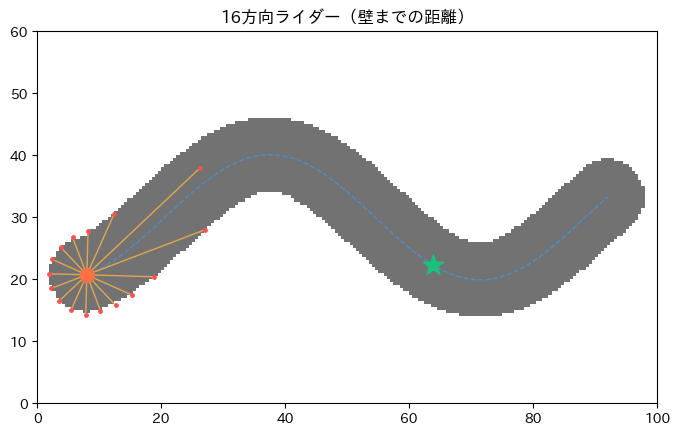

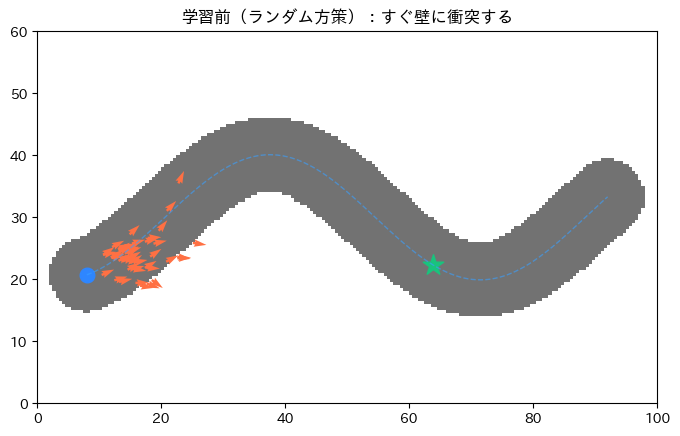

In [ ]:
# --- 環境の動作確認：状態の形・16ライダーの可視化・ランダム走行の様子 ---
env = STrackEnv(n_cars=48, seed=2)
obs = env.reset()
print("状態ベクトルの形:", obs.shape, " (=16ライダー + 速度 + 進行方向誤差sin,cos)")
print("行動数:", env.n_actions, " (ハンドル3 × ペダル3)")
print("道路が占める面積の割合:", round(float(env.free.mean()), 3))

# 16方向ライダーの可視化（1台ぶん）
draw_lidar(env, car_idx=0)

# ランダム方策で一斉に走らせた様子（学習前）
env2 = STrackEnv(n_cars=48, seed=2)
frames = record_rollout(env2, agent=None, max_frames=80)
pos, th, done, reached, over = frames[min(45, len(frames)-1)]
fig, ax = plt.subplots(figsize=(8,5))
ax.imshow(env2.free, origin="lower", extent=[0,env2.WX,0,env2.WY], cmap="Greys",
          vmin=0, vmax=1.6, aspect="equal")
ax.plot(env2.cl[:,0], env2.cl[:,1], "--", color="#3aa0ff", lw=1, alpha=0.6)
ax.quiver(pos[:,0], pos[:,1], np.cos(th)*2.2, np.sin(th)*2.2, color="#ff7043",
          scale=1, scale_units="xy", angles="xy", width=0.004)
ax.scatter([env2.cl[0,0]],[env2.cl[0,1]], c="#2e86ff", s=110, marker="o")
ax.scatter([env2.goal_xy[0]],[env2.goal_xy[1]], c="#19c37d", s=240, marker="*")
ax.set_title("学習前（ランダム方策）：すぐ壁に衝突する"); ax.set_xlim(0,env2.WX); ax.set_ylim(0,env2.WY)
plt.show()


## 3. DQN エージェント（CartPole と同じ骨格）

部品は CartPole の DQN と同じです：Q関数の近似ネット・経験再生・ターゲットネット・ε-greedy・ベルマン更新。
違うのは「状態＝16ライダー＋速度＋向き誤差(19次元)」「行動＝15通り」「多数の車で経験を集める」点だけです。


In [ ]:
# ============================================================================
# 【DQNエージェント】 CartPole のDQNと同じ骨格（部品は同じ）
#   ・QNet         : 状態(19次元) → 各行動(9個)のQ値。Q表の代わり（関数近似）
#   ・ReplayBuffer : 経験再生。多数の車の経験を1つのバッファに貯めてランダム学習
#   ・act_batch    : ε-greedy を全車まとめて（探索と活用）
#   ・replay       : ベルマン更新  L=( r + γ·maxQ(θ⁻) − Q(θ) )²  を最小化
#   ・target       : ターゲットネット（一定間隔で同期して学習を安定化）
# ============================================================================
import torch, torch.nn as nn, torch.nn.functional as F
from collections import deque
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("使用デバイス:", device)

class QNet(nn.Module):
    def __init__(self, obs_dim, n_act, h=128):
        super().__init__()
        self.f1 = nn.Linear(obs_dim, h)
        self.f2 = nn.Linear(h, h)
        self.f3 = nn.Linear(h, n_act)
    def forward(self, x):
        x = F.relu(self.f1(x))
        x = F.relu(self.f2(x))
        return self.f3(x)        # 出力 = 9個の行動それぞれのQ値

class DQNAgent:
    def __init__(self, obs_dim, n_act):
        self.n_act = n_act
        self.policy = QNet(obs_dim, n_act).to(device)   # 主ネット θ（学習中）
        self.target = QNet(obs_dim, n_act).to(device)   # ターゲットネット θ⁻（時々同期）
        self.target.load_state_dict(self.policy.state_dict())
        self.opt = torch.optim.Adam(self.policy.parameters(), 1e-3)
        self.buf = deque(maxlen=100000)                 # 経験再生バッファ
        self.bs = 256
        self.gamma = 0.99                               # 割引率 γ
        self.eps = 1.0; self.eps_min = 0.05; self.eps_decay = 0.995
        self.tgt_every = 500; self._c = 0

    # 全車まとめて ε-greedy で行動選択（探索：ランダム / 活用：Q最大）
    def act_batch(self, obs):
        n = obs.shape[0]
        a = np.random.randint(0, self.n_act, n)         # まず全車ランダム（探索）
        greedy = (np.random.rand(n) >= self.eps)        # 確率(1-ε)で活用に上書き
        if greedy.any():
            with torch.no_grad():
                q = self.policy(torch.tensor(obs[greedy], device=device))
            a[greedy] = q.argmax(1).cpu().numpy()
        return a

    # 多数の車の遷移をまとめてバッファに追加
    def remember_batch(self, s, a, r, s2, d):
        for i in range(len(a)):
            self.buf.append((s[i], a[i], r[i], s2[i], d[i]))

    # ベルマン更新（CartPole の replay() と中身は同じ）
    def replay(self):
        if len(self.buf) < self.bs:
            return None
        batch = random.sample(self.buf, self.bs)
        s, a, r, s2, d = zip(*batch)
        s  = torch.tensor(np.array(s),  device=device)
        a  = torch.tensor(np.array(a),  device=device).long().unsqueeze(1)
        r  = torch.tensor(np.array(r),  device=device).float()
        s2 = torch.tensor(np.array(s2), device=device)
        d  = torch.tensor(np.array(d),  device=device).bool()

        q  = self.policy(s).gather(1, a).squeeze(1)              # Q(s,a; θ): 現在の見積り
        with torch.no_grad():
            nq  = self.target(s2).max(1)[0]                     # max Q(s',·; θ⁻)
            tgt = r + self.gamma * nq * (~d)                    # r + γ·maxQ = TDターゲット
        loss = F.mse_loss(q, tgt)                               # (目標 − 現在)²
        self.opt.zero_grad(); loss.backward(); self.opt.step()

        self._c += 1
        if self._c % self.tgt_every == 0:                      # 時々ターゲットネットを同期
            self.target.load_state_dict(self.policy.state_dict())
        return loss.item()

print("DQNAgent 定義OK")


使用デバイス: cpu
DQNAgent 定義OK


## 4. 学習ループ（時々、走りを動画化）

多数の車で経験を集め、毎ステップ1回ベルマン更新します。
`video_every` エピソードごとに、その時点の方策で **別のコース** を走らせた動画を表示し、上達の様子を確認します。


In [ ]:
# ============================================================================
# 【学習ループ】 多数の車で経験を集めてDQNを学習。時々、走行を動画化して進捗を見る
# ============================================================================
import time

def train(episodes=400, n_cars=48, seed=0, video_every=50, video_max_frames=200):
    np.random.seed(seed); torch.manual_seed(seed); random.seed(seed)
    env   = STrackEnv(n_cars=n_cars, seed=seed)        # 学習用（毎エピソード別のS字）
    eval_env = STrackEnv(n_cars=n_cars, seed=12345)    # 動画用（学習とは別のコース）
    agent = DQNAgent(env.obs_dim, env.n_actions)
    hist = []                                          # (ゴール率, 最大進捗, 平均進捗, 平均リターン)
    t0 = time.time()

    for ep in range(episodes):
        obs = env.reset()
        ep_ret = np.zeros(n_cars)
        while True:
            live = ~env.done
            a = agent.act_batch(obs)
            nobs, r, done, da = env.step(a)
            # 生きていた車の遷移だけ保存（既に終わった車は学習に入れない）
            idx = np.where(live)[0]
            if len(idx):
                agent.remember_batch(obs[idx], a[idx], r[idx], nobs[idx], done[idx])
            ep_ret += r
            obs = nobs
            agent.replay()                              # 毎ステップ1回ベルマン更新
            if da: break

        agent.eps = max(agent.eps_min, agent.eps*agent.eps_decay)
        hist.append((env.reached.mean(), env.s.max(), env.s.mean(), ep_ret.mean()))

        if ep % 10 == 0:
            rr, smax, smean, ret = hist[-1]
            print(f"ep{ep:4d}  ε={agent.eps:.2f}  ゴール率(探索中ε)={rr*100:4.0f}%  "
                  f"最大進捗={smax:.2f}  平均進捗={smean:.2f}  平均リターン={ret:6.1f}")

        # ---- 時々、走行を動画化して表示 ----
        if video_every and (ep % video_every == 0):
            if ep == 0:
                # 学習前のベースライン：ランダム方策（止まらず動いて壁に衝突＝デモ映えする）
                frames = record_rollout(eval_env, agent=None, max_frames=video_max_frames)
                title = "エピソード 0（学習前・ランダム方策）"
            else:
                # 学習中：その時点の方策を探索オフ（実力どおり）で評価
                frames = record_rollout(eval_env, agent, greedy=True, max_frames=video_max_frames)
                title = f"エピソード {ep}"
            path = animate(eval_env, frames, path=f"train_ep{ep:04d}.mp4", title=title)
            if ep == 0:
                print(f"  → 動画 train_ep0000.mp4（学習前・ランダム方策のベースライン）")
            else:
                print(f"  → 動画 train_ep{ep:04d}.mp4（評価ゴール率(貪欲ε=0) {eval_env.reached.mean()*100:.0f}%）")
                print(f"     ※ログの『ゴール率(探索中)』は約{int(agent.eps*100)}%がランダム行動なので低く出る。実力はこの貪欲評価が正しい。")
            show_video(path)

    print(f"学習時間 {time.time()-t0:.1f}s")
    return env, agent, hist

print("train() 定義OK")


train() 定義OK


## 5. 学習の実行

`episodes` を増やすほど上達します（**GPU推奨**）。最初はすぐ壁にぶつかりますが、徐々に
**直線で加速し、コーナー手前で減速して曲がり、出口で再加速**するようになります（ラインのアウトインアウト化）。


In [ ]:
# --- 学習の実行 ---
#   GPU 推奨（ランタイム → ランタイムのタイプを変更 → GPU）。
#   episodes を増やすほど上達する。video_every ごとに走行動画が表示される。
trained_env, agent, hist = train(episodes=400, n_cars=48, seed=0, video_every=80)


ep   0  ε=0.99  ゴール率(探索中ε)=   0%  最大進捗=0.59  平均進捗=0.16  平均リターン= -14.2
  → 動画 train_ep0000.mp4（学習前・ランダム方策のベースライン）


ep  10  ε=0.95  ゴール率(探索中ε)=   0%  最大進捗=0.51  平均進捗=0.15  平均リターン= -10.5
ep  20  ε=0.90  ゴール率(探索中ε)=   0%  最大進捗=0.66  平均進捗=0.16  平均リターン=  -8.6
ep  30  ε=0.86  ゴール率(探索中ε)=   6%  最大進捗=0.69  平均進捗=0.33  平均リターン=  -0.2
ep  40  ε=0.81  ゴール率(探索中ε)=   4%  最大進捗=0.70  平均進捗=0.25  平均リターン=  -2.3
ep  50  ε=0.77  ゴール率(探索中ε)=  10%  最大進捗=0.69  平均進捗=0.31  平均リターン=   4.7
ep  60  ε=0.74  ゴール率(探索中ε)=   4%  最大進捗=0.69  平均進捗=0.33  平均リターン=   4.2
ep  70  ε=0.70  ゴール率(探索中ε)=   6%  最大進捗=0.70  平均進捗=0.24  平均リターン=   1.8
ep  80  ε=0.67  ゴール率(探索中ε)=   4%  最大進捗=0.70  平均進捗=0.30  平均リターン=   4.4
  → 動画 train_ep0080.mp4（評価ゴール率(貪欲ε=0) 100%）
     ※ログの『ゴール率(探索中)』は約66%がランダム行動なので低く出る。実力はこの貪欲評価が正しい。


ep  90  ε=0.63  ゴール率(探索中ε)=  19%  最大進捗=0.70  平均進捗=0.42  平均リターン=  15.5
ep 100  ε=0.60  ゴール率(探索中ε)=  54%  最大進捗=0.70  平均進捗=0.54  平均リターン=  34.9
ep 110  ε=0.57  ゴール率(探索中ε)=  33%  最大進捗=0.71  平均進捗=0.48  平均リターン=  24.3
ep 120  ε=0.55  ゴール率(探索中ε)=  38%  最大進捗=0.69  平均進捗=0.45  平均リターン=  26.2
ep 130  ε=0.52  ゴール率(探索中ε)=  33%  最大進捗=0.70  平均進捗=0.46  平均リターン=  25.1
ep 140  ε=0.49  ゴール率(探索中ε)=  23%  最大進捗=0.70  平均進捗=0.45  平均リターン=  20.5
ep 150  ε=0.47  ゴール率(探索中ε)=  42%  最大進捗=0.69  平均進捗=0.48  平均リターン=  29.5
ep 160  ε=0.45  ゴール率(探索中ε)=  15%  最大進捗=0.68  平均進捗=0.35  平均リターン=  12.2
  → 動画 train_ep0160.mp4（評価ゴール率(貪欲ε=0) 100%）
     ※ログの『ゴール率(探索中)』は約44%がランダム行動なので低く出る。実力はこの貪欲評価が正しい。


ep 170  ε=0.42  ゴール率(探索中ε)=  40%  最大進捗=0.69  平均進捗=0.47  平均リターン=  29.6
ep 180  ε=0.40  ゴール率(探索中ε)=  40%  最大進捗=0.70  平均進捗=0.60  平均リターン=  36.1
ep 190  ε=0.38  ゴール率(探索中ε)=  15%  最大進捗=0.72  平均進捗=0.44  平均リターン=  18.1
ep 200  ε=0.37  ゴール率(探索中ε)=  48%  最大進捗=0.69  平均進捗=0.55  平均リターン=  36.0
ep 210  ε=0.35  ゴール率(探索中ε)=  40%  最大進捗=0.69  平均進捗=0.39  平均リターン=  25.0
ep 220  ε=0.33  ゴール率(探索中ε)=  65%  最大進捗=0.69  平均進捗=0.58  平均リターン=  43.7
ep 230  ε=0.31  ゴール率(探索中ε)=  71%  最大進捗=0.67  平均進捗=0.55  平均リターン=  45.7
ep 240  ε=0.30  ゴール率(探索中ε)=  42%  最大進捗=0.69  平均進捗=0.51  平均リターン=  30.0
  → 動画 train_ep0240.mp4（評価ゴール率(貪欲ε=0) 100%）
     ※ログの『ゴール率(探索中)』は約29%がランダム行動なので低く出る。実力はこの貪欲評価が正しい。


ep 250  ε=0.28  ゴール率(探索中ε)=  73%  最大進捗=0.73  平均進捗=0.69  平均リターン=  51.5
ep 260  ε=0.27  ゴール率(探索中ε)=  42%  最大進捗=0.69  平均進捗=0.44  平均リターン=  28.7
ep 270  ε=0.26  ゴール率(探索中ε)=  73%  最大進捗=0.67  平均進捗=0.56  平均リターン=  47.8
ep 280  ε=0.24  ゴール率(探索中ε)=  65%  最大進捗=0.71  平均進捗=0.57  平均リターン=  43.5
ep 290  ε=0.23  ゴール率(探索中ε)=  69%  最大進捗=0.70  平均進捗=0.57  平均リターン=  44.7
ep 300  ε=0.22  ゴール率(探索中ε)=  71%  最大進捗=0.73  平均進捗=0.62  平均リターン=  46.6
ep 310  ε=0.21  ゴール率(探索中ε)=  83%  最大進捗=0.69  平均進捗=0.66  平均リターン=  54.9
ep 320  ε=0.20  ゴール率(探索中ε)=  90%  最大進捗=0.69  平均進捗=0.67  平均リターン=  57.5
  → 動画 train_ep0320.mp4（評価ゴール率(貪欲ε=0) 100%）
     ※ログの『ゴール率(探索中)』は約20%がランダム行動なので低く出る。実力はこの貪欲評価が正しい。


ep 330  ε=0.19  ゴール率(探索中ε)=  96%  最大進捗=0.68  平均進捗=0.66  平均リターン=  59.8
ep 340  ε=0.18  ゴール率(探索中ε)=  96%  最大進捗=0.71  平均進捗=0.68  平均リターン=  60.3
ep 350  ε=0.17  ゴール率(探索中ε)=  83%  最大進捗=0.70  平均進捗=0.61  平均リターン=  50.0
ep 360  ε=0.16  ゴール率(探索中ε)=  65%  最大進捗=0.70  平均進捗=0.49  平均リターン=  37.9
ep 370  ε=0.16  ゴール率(探索中ε)=  88%  最大進捗=0.69  平均進捗=0.65  平均リターン=  54.2
ep 380  ε=0.15  ゴール率(探索中ε)=  50%  最大進捗=0.70  平均進捗=0.48  平均リターン=  30.4
ep 390  ε=0.14  ゴール率(探索中ε)=  71%  最大進捗=0.70  平均進捗=0.64  平均リターン=  49.6
学習時間 590.6s


## 6. 結果 — 学習曲線と最終走行

`racingline` 的に「直線=高速 / コーナー=減速」になっているか、最終動画と速度で確認できます。


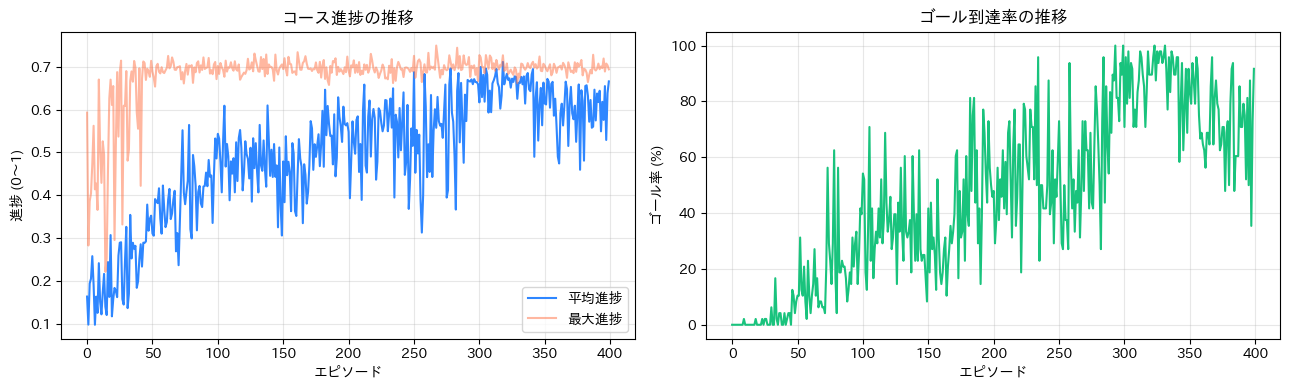

ゴール率: 100%


In [ ]:
# --- 学習曲線（平均進捗・ゴール率の推移）---
H = np.array(hist)  # 列: ゴール率, 最大進捗, 平均進捗, 平均リターン
ep = np.arange(len(H))
fig, ax = plt.subplots(1, 2, figsize=(13,4))
ax[0].plot(ep, H[:,2], color="#2e86ff", label="平均進捗")
ax[0].plot(ep, H[:,1], color="#ff7043", alpha=0.5, label="最大進捗")
ax[0].set_xlabel("エピソード"); ax[0].set_ylabel("進捗 (0〜1)")
ax[0].set_title("コース進捗の推移"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(ep, H[:,0]*100, color="#19c37d")
ax[1].set_xlabel("エピソード"); ax[1].set_ylabel("ゴール率 (%)")
ax[1].set_title("ゴール到達率の推移"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# --- 学習後の方策で、新しいS字コースを走らせた最終動画 ---
final_env = STrackEnv(n_cars=48, seed=999)
frames = record_rollout(final_env, agent, greedy=True, max_frames=250)
path = animate(final_env, frames, path="final_policy.mp4", title="学習後の走行（新コース）")
print(f"ゴール率: {final_env.reached.mean()*100:.0f}%")
show_video(path)


## 7. まとめと発展

**設計の意図**
- 状態を「16方向の距離」に絞ることで、コース形状が変わっても同じ方策が使える（汎化）。
- 行動を15通り（ハンドル5段階×ペダル3）に離散化したので、CartPole と同じ DQN がそのまま使える。
- 報酬は「前進＋速度＋ゴール − 衝突 − 失速 − 時間」の**最短時間**のみ。ラインは教えない。
- **グリップ物理（フリクションサークル）**を入れたことで、最短時間を狙うだけで**アウトインアウト**が創発する。
- 多数の車を並列に走らせるのは経験を速く集めるため（車どうしは衝突させない）。

**調整ポイント**
- `MU_G`（グリップ）：小さいほどコーナーで大きく減速が必要＝ライン取りの差が大きくなる
- `R_PROGRESS / R_SPEED / R_TIME / R_CRASH / R_GOAL / R_STALL`：走りの性格（安全寄り／攻め）
- `half_w`（道幅）、`VMAX`、`MAXSTEER`、コース曲率：難易度とライン自由度
- `n_cars`、`episodes`、`eps_decay`：学習の速さ・安定性

**発展課題**
- 連続制御（DDPG / PPO）でハンドル・アクセルを連続値にし、より滑らかなラインにする
- タイヤ温度・荷重移動などの物理を足して、より本格的なレーシングラインにする
- 車どうしの衝突も入れて、追い越し・譲り合いを学習させる
- 報酬を設計し直して「安全運転」「アタックラップ」など性格の違う方策を作る


**レーサーっぽいかこれ？**

このデモは報酬の微妙なさじ加減を繰り返したものである。少し報酬の値を変えるだけで、全員がのろまなレーサーになる。例えば衝突のペナルティを大きくしたら、慎重運転になるのは当然。そう考えると、このデモはかなり恣意的にレーシングの動きを意図したものといえる。